In [5]:
print("test")

test


In [6]:
#Charger dataset
from datasets import load_dataset
import numpy as np

c:\S8\AI\Sentiment Analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
ds = load_dataset("imdb") #the datasets library recognizes "imdb" as a predefined dataset.

In [8]:
ds
#Le dataset est composé de 3 parties : train et test, que nous utiliserons, et unsupervised que nous n’utiliserons pas.
#Chaque partie contient des exemples de critiques de films avec leur sentiment associé (positif ou négatif).

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [9]:
train_df = ds['train'].to_pandas()
#to_pandas() pour convertir en Pandas DataFrame :
# facile à afficher, filtrer, analyser
# compatible avec beaucoup de libs (matplotlib, sklearn, etc.)

In [10]:
# train_df.head()
train_df.sample(5)

,text,label
11451,Fairly amusing piece that tries to show how sm...,0
15571,This is hands down the greatest stand up show ...,1
2521,"I've seen many horror shows over the years, li...",0
3486,"""The Incubus"" is a mix of the good (an interes...",0
4795,I do not watch much television and came across...,0


In [11]:
#vérifier si le dataset est équilibré:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [12]:
# train_df['sentiment'] = train_df['label'].map({0: 'negative', 1: 'positive'})
train_df['sentiment'] = np.where(train_df['label']==1, "positive","negative")

In [13]:
train_df
#train_df['sentiment'] same as train_df.sentiment

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative
3,This film was probably inspired by Godard's Ma...,0,negative
4,"Oh, brother...after hearing about this ridicul...",0,negative
...,...,...,...
24995,A hit at the time but now better categorised a...,1,positive
24996,I love this movie like no other. Another time ...,1,positive
24997,This film and it's sequel Barry Mckenzie holds...,1,positive
24998,'The Adventures Of Barry McKenzie' started lif...,1,positive


In [14]:
train_df.sentiment.value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

<Axes: >

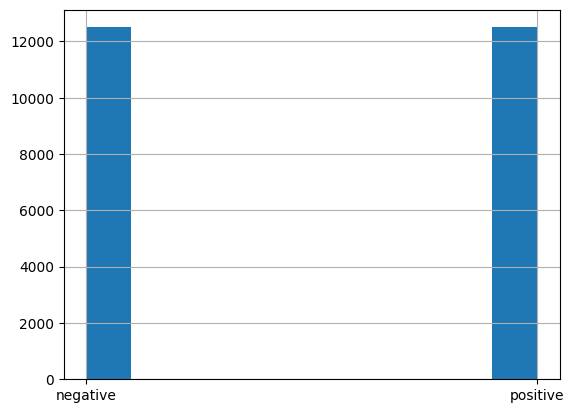

In [15]:
train_df.sentiment.hist()

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
examples_df, gold_examples_df = train_test_split(
    train_df, test_size=0.2, random_state=123
    #0.2 cad 20% examples rest gold_examples
)

In [18]:
examples_df.shape, gold_examples_df.shape

((20000, 3), (5000, 3))

In [19]:
columns = ["text", "sentiment"]
gold_examples = (
                 gold_examples_df[columns]
                 .sample(20, random_state=34)
                 .to_json(orient="records")#Très pratique pour envoyer à un LLM/API.
                ) 

In [20]:
import json

In [21]:
json.loads(gold_examples)[0]

{'text': '"A Guy Thing" may not be a classic, but it sure is a good, funny comedy. The plot focuses on Paul (Jason Lee), who wakes up the morning after his bachelor party with no memory and Becky (Julia Stiles) lying naked in his bed. Before he can figure out what happened, he rushes Becky out of his apartment because his fiance Karen (Selma Blair) is coming. After that, as you could imagine, chaos ensues.<br /><br />Almost every single scene in "A Guy Thing" delivers loud laughs. The funniest moments come from when Paul imagines what could happen if he tells Karen. Selma Blair is a truly talented comedian, and the worst thing about this film is that she goes underused. Although, she turns out to be more funny than Stiles\' character, who actually isn\'t that interesting. Of course, not every comedy is perfect.<br /><br />As I said, "A Guy Thing" is no classic, but it\'s not bad either, 7/10.',
 'sentiment': 'positive'}

## Elaborer les prompts

#### Prompt 1: Zero-shot

In [22]:
user_prompt_template = """```{movie_review}```"""

In [23]:
zero_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
""" 

In [24]:
zero_shot_prompt = [
    {"role":"system", "content": zero_shot_system_message}
]

In [25]:
few_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
""" 

In [26]:
#pour le few shot prompt nous aurons besoin de quelques exemples variés, cad des critiques positives et négatives
#on va diviser les examples on deux (positive et negative) et prendre 4 exemples de chaque pour les inclure in random order dans le prompt few shot
examples_df.shape

(20000, 3)

In [27]:
positive_reviews_df = (
        examples_df[examples_df.sentiment=="positive"][columns]
        .sample(4)
)

In [28]:
negative_reviews_df = (
                examples_df[examples_df.sentiment=="negative"][columns]
                .sample(4))

In [29]:
negative_reviews_df

,text,sentiment
11844,Oh if only I could give this rubbish less than...,negative
9438,This appalling film somehow saw the light of d...,negative
4686,Remakes (and sequels) have been a staple of Ci...,negative
1465,this film has its good points: hot chicks peop...,negative


In [30]:
positive_reviews_df.shape, negative_reviews_df.shape

((4, 2), (4, 2))

In [31]:
import pandas as pd

In [32]:
ex = pd.concat([positive_reviews_df, negative_reviews_df])

In [33]:
ex
#problème : les exemples positifs sont regroupés et les négatifs aussi, il faut les mélanger

,text,sentiment
19872,I own Ralph Bakshis forgotten masterpiece Fire...,positive
21506,"Based on fact, this is the story of a teenager...",positive
22781,"We so often talk of cinema landmarks - Kane, T...",positive
16193,While the story of a troubled kid turning to b...,positive
11844,Oh if only I could give this rubbish less than...,negative
9438,This appalling film somehow saw the light of d...,negative
4686,Remakes (and sequels) have been a staple of Ci...,negative
1465,this film has its good points: hot chicks peop...,negative


In [34]:
examples = examples_df.sample(4*2, replace=False).to_json(orient='records')

In [35]:
json.loads(examples)

[{'text': 'It is important not to be insulted by lack of logic or common sense and those who have any "gray matters" will agree that this movie just doesn\'t work.<br /><br />The problems lay in the direction, cast selections and lack of depth in the character building. The word comedy was very hard thing to say when i expect to laugh when these words are used. Let\'s look at the problems in direction/script.<br /><br />Brother and sister both in their mid 30\'s seem to be well adjusted. They meet a complete stranger at a park and Heather Graham character walks up to her and asks the most intimate questions that even half sane person would be running the other way or at least scream for a police officer. He then awkwardly walks over and makes some stupid statements and she falls for him. Then after ONE date were they all go out together he falls in love with her and decides to get married in Vegas in a week\'s time???? Hello does anyone feel stupid yet? He goes out with thousands of wo

In [36]:
def create_examples(dataset, n=4):
    positive_reviews_df = (
                dataset[dataset['sentiment'] == 'positive'][columns]
                .sample(n)
                )
    negative_reviews_df = (
                dataset[dataset['sentiment'] == 'negative'][columns]
                .sample(n)
                )

    examples_df = pd.concat([positive_reviews_df, negative_reviews_df])
    examples = examples_df.sample(2*n, replace=False)
    
    return examples.to_json(orient='records')

In [37]:
examples_df.shape

(20000, 3)

In [38]:
few_shot_examples = create_examples(examples_df, n=1)

In [39]:
json.loads(few_shot_examples)

[{'text': "i watched this movie 10 years ago. and have watched it on video an average of once a year since. it's the type of movie that's timeless, because the themes are universal, yet the stories and conversation are so personal. it's also one of the very few movies that capture you from frame one til the credits roll, despite the fact that there are, really, just two (very involving) characters. this owes a lot to the engaging acting by hawke and delpy, who make us believe that they are actually jesse and celine. this is also the first movie i saw that mentioned reality TV, and now, the phenomenon is rampant! i love the way this movie just envelops the audience in its space, and makes you think, however jaded you may be, that you are one of those characters. it also made me want to ride the train around Europe! i have not met anyone who has not been able to relate to this movie. maybe that speaks about myself, my friends, or just the sheer genius of this movie.",
  'sentiment': 'pos

In [40]:
#few shot propt fct:
def create_few_shot_prompt(system_message, examples, user_prompt_template):
    few_shot_prompt = [
        {"role": "system", "content": system_message},
    ]

    for example in json.loads(examples) : 
        review = example["text"]
        sentiment = example["sentiment"]
        few_shot_prompt.append({"role": "user", "content": user_prompt_template.format(movie_review=review)})
        few_shot_prompt.append({"role": "assistant", "content": f"{sentiment}"}) 
        #la format f"{}" c'est juste pour spécifier que c est du text

    return few_shot_prompt

In [41]:
few_shot_prompt = create_few_shot_prompt(few_shot_system_message, few_shot_examples, user_prompt_template)

In [42]:
few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks ``` in the input.\nAnswer only 'positive' or 'negative'\nDo not explain your answer.\n"},
 {'role': 'user',
  'content': "```i watched this movie 10 years ago. and have watched it on video an average of once a year since. it's the type of movie that's timeless, because the themes are universal, yet the stories and conversation are so personal. it's also one of the very few movies that capture you from frame one til the credits roll, despite the fact that there are, really, just two (very involving) characters. this owes a lot to the engaging acting by hawke and delpy, who make us believe that they are actually jesse and celine. this is also the first movie i saw that mentioned reality TV, and now, the phenomenon is rampant! i love the way this movie just envelops the audience in its space, and makes you think

## Chain of thought

In [43]:
#cot: chain of thought prompting, c'est une technique qui consiste à demander au modèle de raisonner étape par étape pour arriver à la réponse finale(instructions a suivre)
cot_few_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.

Instructions:
1.Carefully read the text of the review and think through the options for sentiment provided. 
2.Consider the overall sentiment of the review and estimate the probability of the review being positive or negative

To reiterate, your answer should strictly only contain the labels: positive or negative.
"""

In [44]:
cot_few_shot_prompt = create_few_shot_prompt(
                        cot_few_shot_system_message, 
                        few_shot_examples, 
                        user_prompt_template
                        )

In [45]:
cot_few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks ``` in the input.\nAnswer only 'positive' or 'negative'\nDo not explain your answer.\n\nInstructions:\n1.Carefully read the text of the review and think through the options for sentiment provided. \n2.Consider the overall sentiment of the review and estimate the probability of the review being positive or negative\n\nTo reiterate, your answer should strictly only contain the labels: positive or negative.\n"},
 {'role': 'user',
  'content': "```i watched this movie 10 years ago. and have watched it on video an average of once a year since. it's the type of movie that's timeless, because the themes are universal, yet the stories and conversation are so personal. it's also one of the very few movies that capture you from frame one til the credits roll, despite the fact that there are, really, just two (very invo

## Evaluation des trois prompts avec ollama

In [46]:
from sklearn.metrics import f1_score

In [47]:
#fct d'évalutions des prompt:
def evaluate_prompt(prompt, gold_examples, user_prompt_template, llm='llama3.2'):
    predicted_sentiments = []
    ground_truth_sentiments=[]

    for example in json.loads(gold_examples) : 
        review = example["text"]
        sentiment = example["sentiment"]
        user_input = {"role":"user", "content": user_prompt_template.format(movie_review=review)} 

        try:
            resp = llm.invoke(prompt + [user_input])
            if 'negative' in resp.content.strip().lower():
                predicted = 'negative'

            elif 'positive' in resp.content.strip().lower():
                predicted = 'positive'

            else:
                predicted = 'unknown'

            predicted_sentiments.append(predicted)
            ground_truth_sentiments.append(sentiment)

            #print(predicted, sentiment)

        except Exception as e:
            print(f"Error processing review: {e}")
            predicted = 'error'
            continue
    return f1_score(ground_truth_sentiments, predicted_sentiments, average='micro')


In [48]:
#Pour évaluer un prompt il faut d'abord définir les mesures d'évaluation, 
#Les plus courantes sont la précision, le rappel et le F1-score, accuracy(trop simple). 

#on utilisera:
#score micro-F1 = 2 * (precision * recall) / (precision + recall)


In [ ]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="llama3.2", temperature=0)

In [50]:
evaluate_prompt(zero_shot_prompt, gold_examples, user_prompt_template, llm)

0.9

In [51]:
evaluate_prompt(few_shot_prompt, gold_examples, user_prompt_template, llm)

0.95

In [52]:
evaluate_prompt(cot_few_shot_prompt, gold_examples, user_prompt_template, llm)

0.95

In [ ]:
#now we will run multiple evaluation runs to get a more robust estimate of the performance of each prompt, and calculate the mean(the average) and std(the standard deviation) of the scores across runs. 
from tqdm import tqdm

num_eval_runs = 10
performances = []

for _ in tqdm(range(num_eval_runs)):
    examples = create_examples(examples_df, n=4)
    fsp = create_few_shot_prompt(few_shot_system_message, examples, user_prompt_template)
    score = evaluate_prompt(fsp, gold_examples, user_prompt_template, llm)
    performances.append(score)
mean = np.array(performances).mean()
std = np.array(performances).std()
print(f"Mean: {mean}, Std: {std}")
#vous pouvez utiliser google collab si votre machine n'est pas assez puissante pour faire tourner le modèle localement, ou si vous voulez juste tester rapidement.

100%|██████████| 10/10 [3:35:31<00:00, 1293.15s/it] 

Mean: 0.8949999999999999, Std: 0.04153311931459037
